# Tiny volumes in Colab
*Author: Vedrana Andersen Dahl (vand@dtu.dk)*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vedranaa/teaching-notebooks/blob/main/Volume_data_in_colab.ipynb)

Prepared for workshop *Image Analysis for Scientific Applications*, Uppsala, February 2022

In [1]:
# Load packages.
import numpy as np
import skimage.io
import matplotlib.pyplot as plt

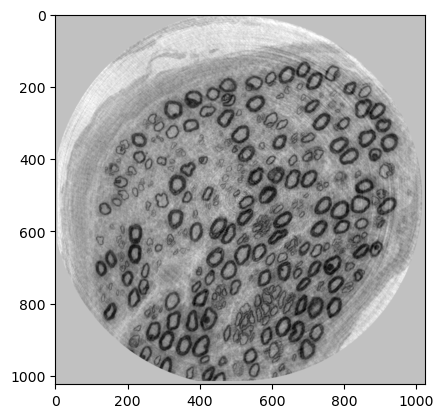

In [2]:
# Load and visualize an image from QIM data repository.
url = 'https://data.qim.dk/InSegt_data/2D/NT2_0001.png'
image = skimage.io.imread(url)
plt.imshow(image, cmap=plt.cm.gray)
plt.show()

## A small part of composite fibres data
Tif volumes may also be loaded from the internet using a similar approach as images. However, this is practical only for rather small volumes, as this tiny part of scan of composite materials. 



Loading the volume...
Volume shape is: (150, 150, 150)
Volume data type is: uint8
Intensity range is: 25-223


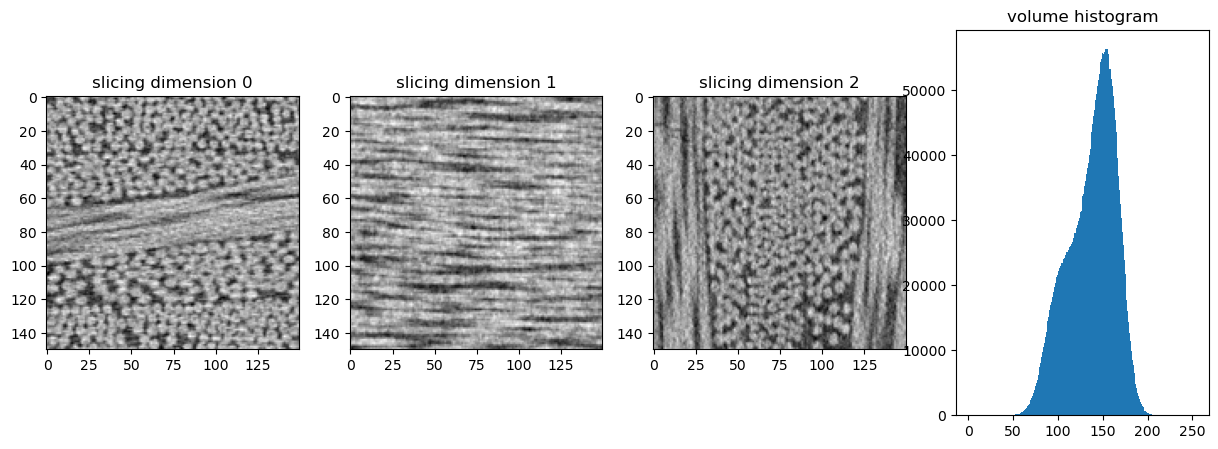

In [3]:
# Load and visualize a volume from QIM data repository.
url = 'https://data.qim.dk/demo_data/multicube.tif'
print('Loading the volume...')

vol = skimage.io.imread(url)

print(f'Volume shape is: {vol.shape}')
print(f'Volume data type is: {vol.dtype}')
print(f'Intensity range is: {vol.min()}-{vol.max()}')

fig, ax = plt.subplots(1, 4, figsize=(15,5))
ax[0].imshow(vol[vol.shape[0]//2], cmap=plt.cm.gray)
ax[0].set_title('slicing dimension 0')
ax[1].imshow(vol[:, vol.shape[1]//2, :], cmap=plt.cm.gray)
ax[1].set_title('slicing dimension 1')
ax[2].imshow(vol[:, :, vol.shape[2]//2], cmap=plt.cm.gray)
ax[2].set_title('slicing dimension 2')
ax[3].hist(vol.ravel(), np.arange(257)-0.5)
ax[3].set_title('volume histogram')
plt.show()

In [ ]:
# Retreive module for 3D visualization using plotly
import os

if not os.path.isfile('volvizplotly.py'):
    !wget 'https://raw.githubusercontent.com/vedranaa/goodies/main/volvizplotly.py' -q

import  volvizplotly as vvp
vvp.volume_slicer(vol, ['ends','ends','ends'])

In [ ]:
vvp.volume_slicer(vol, ['mid','mid','mid'])

## A small part of nerves data

Retreive the volume from qim repositiry and visualize the volume as before.

In [6]:
# Retrieve volume from QIM data repository.
!wget 'https://data.qim.dk/InSegt_data/3D/nerves_part.tiff' -q

Volume shape is: (1024, 350, 350)
Volume data type is: uint8
Intensity range is: 0-236


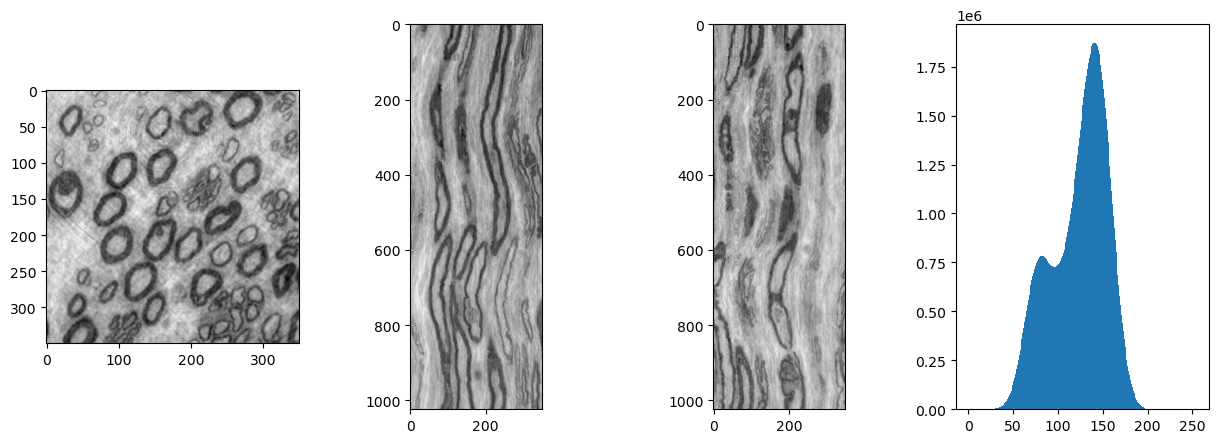

In [7]:
# Load volume.
vol = skimage.io.imread('nerves_part.tiff')

print(f'Volume shape is: {vol.shape}')
print(f'Volume data type is: {vol.dtype}')
print(f'Intensity range is: {vol.min()}-{vol.max()}')

# Visualize volume slices and histogram
fig, ax = plt.subplots(1, 4, figsize=(15,5))
ax[0].imshow(vol[vol.shape[0]//2], cmap=plt.cm.gray)
ax[1].imshow(vol[:, vol.shape[1]//2, :], cmap=plt.cm.gray)
ax[2].imshow(vol[:, :, vol.shape[2]//2], cmap=plt.cm.gray)
ax[3].hist(vol.ravel(), np.arange(257)-0.5)
plt.show()

In [ ]:
# Visualize part of the volume.
vvp.volume_slicer(vol[:400], ['ends','ends','ends'])

## More advanced: showing a meshed surface

In [ ]:
import skimage.measure

V = vol[60:90, 240:293, 235:292]
S = V<85

# Use marching cubes to obtain the surface mesh 
verts, faces, _, _ = skimage.measure.marching_cubes(V, 85)

fig = vvp.volume_slicer(V, ['mid', 'mid', 'mid'], show=False)
vvp.show_mesh(verts, faces, surface_opacity=0.5, fig=fig)